# IQIQML project 3
## Maciej Woś, 148276

In [3]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit_aer import Aer
from qiskit.visualization import *
from random import randint

Task 1

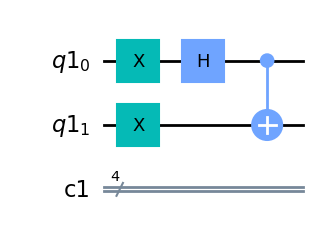

In [4]:
backend = Aer.get_backend('qasm_simulator')
qr = QuantumRegister(2)
cr = ClassicalRegister(4)
charlie = QuantumCircuit(qr, cr)
charlie.x(qr[0])
charlie.x(qr[1])
charlie.h(qr[0])
charlie.cx(qr[0], qr[1])
charlie.draw(output= 'mpl')

Task 2

In [51]:
a1 = QuantumCircuit(qr, cr)
a1.h(qr[0])
a1.measure(qr[0],cr[0])

a2 = QuantumCircuit(qr, cr)
a2.s(qr[0])
a2.h(qr[0])
a2.t(qr[0])
a2.h(qr[0])
a2.measure(qr[0],cr[0])

a3 = QuantumCircuit(qr, cr)
a3.measure(qr[0],cr[0])

b1 = QuantumCircuit(qr, cr)
b1.s(qr[1])
b1.h(qr[1])
b1.t(qr[1])
b1.h(qr[1])
b1.measure(qr[1],cr[1])

b2 = QuantumCircuit(qr, cr)
b2.measure(qr[1],cr[1])

b3 = QuantumCircuit(qr, cr)
b3.s(qr[1])
b3.h(qr[1])
b3.tdg(qr[1])
b3.h(qr[1])
b3.measure(qr[1],cr[1])

alice = [a1, a2, a3]
bob = [b1, b2, b3]

alice_choice = []
bob_choice = []

for _ in range(1024):
    alice_choice.append(randint(1, 3))
    bob_choice.append(randint(1, 3))

measurements = []
for i in range(1024):
    a = alice_choice[i]
    b = bob_choice[i]
    combined = QuantumCircuit()
    combined = charlie & alice[a-1] & bob[b-1]
    combined.name = "a" + str(i) + ": " + str(a) + ", b" + str(i) + ": " + str(b)
    measurements.append(combined)

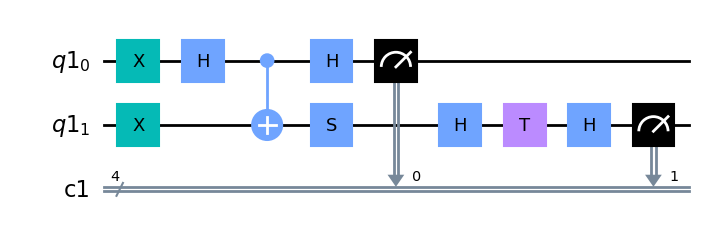

In [52]:
measurements[0].draw(output='mpl')

Task 3

In [53]:
new_qc = transpile(measurements, backend)
job_sim = backend.run(new_qc, shots=1)
result = job_sim.result()
alice_results = []
bob_results = []

for i in range(1024):
    res = list(result.get_counts(measurements[i]).keys())[0]
    res2 = res[-2:]
    if res2 == '00':
        alice_results.append(-1)
        bob_results.append(-1)
    if res2 == '01':
        alice_results.append(1)
        bob_results.append(-1)
    if res2 == '10':
        alice_results.append(-1)
        bob_results.append(1)
    if res2 == '11':
        alice_results.append(1)
        bob_results.append(1)

Task 4

In [54]:
alice_key = []
bob_key = []

for i in range(1024):
    if (alice_choice[i] == 2 and bob_choice[i] == 1) or (alice_choice[i] == 3 and bob_choice[i] == 2):
        alice_key.append(alice_results[i])
        bob_key.append(-bob_results[i])
    
keys_length = len(alice_key)
mismatches = 0

for j in range(keys_length):
    if alice_key[j] != bob_key[j]:
        mismatches += 1  

Task 5

In [65]:
def expectation(counters):
    total_counters = sum(counters)
    if total_counters > 0:
        return (counters[0] - counters[1] - counters[2] + counters[3]) / total_counters
    else:
        return 0

def chsh_corr(result):
    counters = {key: [0] * 4 for key in [(1, 1), (1, 3), (3, 1), (3, 3)]}
    binary_to_index = {'00': 0, '01': 1, '10': 2, '11': 3}
    
    for i, measure in enumerate(measurements[:1024]):
        res = list(result.get_counts(measure).keys())[0]
        outcome_index = binary_to_index[res[-2:]]
        key = (alice_choice[i], bob_choice[i])
        if key in counters:
            counters[key][outcome_index] += 1
        
    e11 = expectation(counters[(1, 1)])
    e13 = expectation(counters[(1, 3)])
    e31 = expectation(counters[(3, 1)])
    e33 = expectation(counters[(3, 3)])

    chsh_value = e11 - e13 + e31 + e33
    return chsh_value

Task 6

In [67]:
print("1)")
print("Alice's key has length of " + str(len(alice_key)))
print("Bob's key has length of " + str(len(bob_key)))
print("2)")
print("The total number of mismatching bits is " + str(mismatches))
chsh = chsh_corr(result)
print("3)")
print("The calcluated CHSH correlation value is " + str(chsh))

1)
Alice's key has length of 235
Bob's key has length of 235
2)
The total number of mismatching bits is 0
3)
The calcluated CHSH correlation value is -2.8671862513186075
